# A GeoSpatial Analysis of Health Access, Service Requests, and Surveillance in Detroit

Evelyn Bartley & Megan Allen

# Notebook Initialization

Note: A majority of the coding work was done in a DeepNote environment, and then transferred to the Vocareum Jupyter environment.

## Dependencies

This notebook uses the following external libraries: 
- geopandas==1.0.1
- pandas==2.1.4
- matplotlib==3.8.4
- nbconvert==7.17.0
- folium==0.20.0
- cmocean==4.0.3
- requests==2.32.5
- shapely==2.1.2

This notebook uses the following built-in modules:
- datetime
- time

## Install Packages

Run the code block below to install specific dependencies. You only have to run this code chunk once at the beginning of your time in this notebook. It can be commented out or deleted once your environment has these packages installed.

In [1]:
# The --quiet command suppresses the installation output 
# The --disable-pip-version-check suppresses the "upgrade pip" notice

# we used pip==24.0
!pip install --quiet --disable-pip-version-check \
    cmocean==4.0.3 \
    folium==0.20.0 \
    geopandas==1.0.1 \
    matplotlib==3.8.4 \
    nbconvert==7.17.0 \
    pandas==2.1.4 \
    requests==2.32.5 \
    shapely==2.1.2 

Use the !pip freeze command to display a list of all installed packages and their versions:

In [2]:
#!pip freeze

## Import libraries

In [3]:
# Load json to parse JSON text for functions module
import json

# Load sys so Python can locate files in list of directories
import sys

# Load os to get the current directory path
import os

# load inspect to examine Python objects
import inspect

# Load geopandas library to work with geoJSON files.
import geopandas as gpd

# Load pandas library for data manipulation and analysis.
import pandas as pd

# Load matplotlib library for data visualization.
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load folium to visualize geospatial data.
import folium

# Load cmocean for colormaps.
import cmocean.cm as cmo

# Load datetime to manipulate dates and times.
from datetime import datetime

# Load requests to conduct HTTP requests to an API.
import requests

# Load time so we can time and optimize queries.
import time

# Load Point to use in coordinate mapping.
from shapely.geometry import Point

# for cloropleth map function
from branca.element import MacroElement

# for cloropleth map function
from jinja2 import Template

## Import Functions Module

As we created this notebook, we wrote a collection of user-defined functions specifically for our project. Once those functions were finalized, we transferred all of them into a separate notebook, and then downloaded it as a .ipynb file.

Here is a step-by-step of that process:

1. Cut all defined functions from the Main Notebook and paste them into the Functions Module Notebook within this DeepNote project. 
2. Download the Functions Module notebook as a .py file titled 'functions.py'.
3. Upload the functions.py file to our public GitHub repository.
4. Copy/Paste the raw file URL and load it into the DeepNote Main Notebook.

When new functions are added to the Functions Module Notebook, we can download the updated notebook and overwrite the functions.py file within the GitHub repository with the new file contents.

## Load Functions Module

We need to load the functions module that contains our user-defined functions for this project. We will do this with a GET request.

In [4]:
# Add current directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

url = "https://raw.githubusercontent.com/evba-commit/MADS-Milestone-I/refs/heads/main/functions.ipynb"
response = requests.get(url)
notebook = json.loads(response.text)

# Extract all code cells and write to .py file
code_cells = []
for cell in notebook['cells']:
    if cell['cell_type'] == 'code':
        code_cells.append(cell['source'])

# Join all code cells with double newlines
python_code = '\n\n'.join([''.join(cell) if isinstance(cell, list) else cell for cell in code_cells])

# Write to .py file
with open('functions.py', 'w') as f:
    f.write(python_code)

# Verify the file was created
print("File created at:", os.path.join(current_dir, 'functions.py'))
!ls -la functions.py

File created at: /voc/work/functions.py
-rw-r--r-- 1 labsuser users 35656 Feb 16 01:02 functions.py


Now that the module was written, we can import it into our notebook.

In [5]:
# Now import functions as a module
import functions

Let's print the names of each function in the functions module.

In [6]:
# Show all Python functions contained in the functions module
funcs = [name for name, obj in inspect.getmembers(functions) 
         if inspect.isfunction(obj)]
funcs

['assign_points_to_neighborhood',
 'calculate_district_imu',
 'council_district_stats',
 'create_map',
 'create_map_orig',
 'density_per_neighborhood',
 'df_to_geodataframe',
 'flag_underserved_with_green_lights',
 'group_and_sum',
 'min_max',
 'neighborhood_choropleth_map',
 'points_in_neighborhood_map',
 'summarize_dataframe']

In order to call our functions from the functions module without prefacing with "functions." before the functions call, we can import *.

In [7]:
from functions import *

# Load Data

## Datasets

1. Current City of Detroit Neighborhoods \
https://data.detroitmi.gov/datasets/detroitmi::current-city-of-detroit-neighborhoods/about
2. Project Green Light Locations \
https://data.detroitmi.gov/datasets/detroitmi::project-green-light-locations/about
3.  Medically Underserved Areas Population \
https://data.detroitmi.gov/datasets/detroitmi::medically-underserved-areas-population/about
4.  Improve Detroit Issues \
https://data.detroitmi.gov/datasets/detroitmi::improve-detroit-issues/about

## Load Data from GitHub

Load Files from GitHub Repository and Save

In [8]:
# Copy and pasted urls from the raw files in GitHub.
current_neighborhoods_url = 'https://raw.githubusercontent.com/meeallen/Detroit-Data/refs/heads/main/Current_City_of_Detroit_Neighborhoods_Data.geojson'
green_light_url = 'https://raw.githubusercontent.com/meeallen/Detroit-Data/refs/heads/main/Project_Green_Light_Data.geojson'
medically_underserved_url = 'https://raw.githubusercontent.com/meeallen/Detroit-Data/refs/heads/main/Medically_Underserved_Areas_Population_Data.csv'


# Read in and save each file as a GeoDataFrame or DataFrame.
current_neighborhoods_gdf = gpd.read_file(current_neighborhoods_url)
green_light_gdf = gpd.read_file(green_light_url)
medically_underserved_df = pd.read_csv(medically_underserved_url)

## Load Data From API

I used multiple strategies to speed up the retrieval process:
* Specified columns to retrieve so we weren't wasting time on irrelevant columns
* Used a session object so we aren't establishing a new connection for each request
* Used ObjectId range queries instead of offsetting the result by 1000

In [9]:
#original

# This chunk is an optimized API request to load in the Improve Detroit Issues App Data.

# Start the timer.
start_time = time.time()

# Define which columns to retrieve in our request (as a comma separated string).
relevant_variables = 'ObjectId,request_type,status,report_method,priority_code,num_days_to_close,num_hours_to_close,neighborhood,council_district,zip_code'

# store the ArcGIS Feature Service endpoint for Improve Detroit Issues data
base_url = "https://services2.arcgis.com/qvkbeam7Wirps6zC/arcgis/rest/services/improve_detroit/FeatureServer/0/query"

# create session object
session = requests.Session()

# Get the min and max ObjectId to develop range
stats_params = {
    'where': '1=1',
    'outStatistics': '[{"statisticType":"min","onStatisticField":"OBJECTID","outStatisticFieldName":"min_objectid"},{"statisticType":"max","onStatisticField":"OBJECTID","outStatisticFieldName":"max_objectid"}]',
    'f': 'json'
}

stats_response = session.get(base_url, params = stats_params)
stats_data = stats_response.json()
min_objectid = stats_data['features'][0]['attributes']['min_objectid']
max_objectid = stats_data['features'][0]['attributes']['max_objectid']

print(f"ObjectId range: {min_objectid} to {max_objectid}")

# Query in chunks using ObjectId ranges.
records = []
batch_size = 1000
current_objectid = min_objectid

while current_objectid <= max_objectid:
    next_objectid = current_objectid + batch_size
    
    params = {
        'where': f'OBJECTID >= {current_objectid} AND OBJECTID < {next_objectid}',
        'outFields': relevant_variables,
        'f': 'json',
        'returnGeometry': 'true'
    }
    
    response = session.get(base_url, params = params)
    data = response.json()
    
    # Check if we got any features
    if 'features' in data and len(data['features']) > 0:
        # Process the features
        for feature in data['features']:
            record = feature['attributes'].copy()
            if 'geometry' in feature and feature['geometry']:
                record['longitude'] = feature['geometry'].get('x')
                record['latitude'] = feature['geometry'].get('y')
            else:
                record['longitude'] = None
                record['latitude'] = None
            records.append(record)
        #print(f"Retrieved {len(records)} records so far... (ObjectId {current_objectid}-{next_objectid})")
    current_objectid = next_objectid

session.close()

improve_detroit_df = pd.DataFrame(records)

# end timer
end_time = time.time()
# calculate time elapsed
elapsed_time = end_time - start_time

print(f"Total records retrieved: {len(improve_detroit_df)}.")
print(f"Time taken: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


ObjectId range: 1 to 686362
Total records retrieved: 686362.
Time taken: 114.18 seconds (1.90 minutes)


API request run-time log:

2/13/26 1:40pm: 1.94 minutes

2/14/26 12:23pm: 1.66 minutes

2/14/26 12:58pm: 1.77 minutes

2/14/26 7:28pm: 1.95 minutes

# Data Processing and Manipulation

## Process Current City of Detroit Neighborhoods GeoDataFrame

First, determine which columns to keep. We want to keep relevant columns for our analysis and discard columns that we will not use. Let's first look at the columns we have.

In [10]:
current_neighborhoods_gdf.columns

Index(['OBJECTID', 'council_district', 'nhood_num', 'nhood_name', 'Website',
       'geometry'],
      dtype='object')

There are six columns: 'OBJECTID', 'council_district', 'nhood_num', 'nhood_name', 'Website',
 and 'geometry'. 

We can view the first five rows with .head().

In [11]:
current_neighborhoods_gdf.head()

,OBJECTID,council_district,nhood_num,nhood_name,Website,geometry
0,1,4,103,West End,https://theneighborhoods.org/neighborhoods/wes...,"POLYGON ((13494856.979 325327.727, 13494597.33..."
1,2,4,105,Chandler Park,https://theneighborhoods.org/neighborhoods/cha...,"POLYGON ((13499061.648 327198.169, 13499013.29..."
2,3,4,100,Riverbend,https://theneighborhoods.org/neighborhoods/riv...,"POLYGON ((13501258.54 325179.803, 13501260.653..."
3,4,4,101,Jefferson Chalmers,https://theneighborhoods.org/neighborhoods/jef...,"POLYGON ((13505873.932 314808.976, 13505467.10..."
4,5,1,29,Riverdale,https://theneighborhoods.org/neighborhoods/riv...,"POLYGON ((13422868.412 335274.832, 13422935.53..."


We can use our summarize_dataframe function:

In [12]:
summarize_dataframe(current_neighborhoods_gdf)

,Type,Missing,Missing %,Unique,min,max,mean
OBJECTID,int32,0,0.0,205,1.0,215.0,103.91
council_district,int32,0,0.0,7,1.0,7.0,3.97
nhood_num,int32,0,0.0,205,1.0,209.0,104.08
nhood_name,object,0,0.0,205,NaN,NaN,NaN
Website,object,0,0.0,204,NaN,NaN,NaN
geometry,geometry,0,0.0,205,NaN,NaN,NaN


Let's specify which columns to keep in our DataFrame.\
We will not use 'OBJECTID' because we can use the neighborhood name or number as the unique identifier.\
We will not use 'Website' because we do not need the URL of each neighborhood website.

In [13]:
current_neighborhoods_gdf = current_neighborhoods_gdf[
    ['council_district', 'nhood_num', 'nhood_name', 'geometry']
    ]

We will rename two columns for clarification.

In [14]:
current_neighborhoods_gdf = current_neighborhoods_gdf.rename(columns = {
    'nhood_num': 'neighborhood_number', 'nhood_name': 'neighborhood_name'}
    )

We can now examine each column's data type and modify it if necessary.

In [15]:
current_neighborhoods_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   council_district     205 non-null    int32   
 1   neighborhood_number  205 non-null    int32   
 2   neighborhood_name    205 non-null    object  
 3   geometry             205 non-null    geometry
dtypes: geometry(1), int32(2), object(1)
memory usage: 4.9+ KB


We'll change the data type for the columns 'council_district' and 'neighborhood_number' to strings since they are labels, and 'neighborhood_name' will remain an object since it is an identifier.

In [16]:
current_neighborhoods_gdf = current_neighborhoods_gdf.astype(
    {
    'council_district': 'str',
    'neighborhood_number': 'str'
    }
    )

Let's add a column that calculates the area of each neighborhood in square miles, for our upcoming analysis.

In [17]:
# Make a copy
current_neighborhoods_gdf = current_neighborhoods_gdf.copy()

# Set the coordinate reference system to US survey feet, Michigan South
current_neighborhoods_gdf = current_neighborhoods_gdf.to_crs(epsg = 2253)

# Calculate the area of each neighborhood in square miles, and round
current_neighborhoods_gdf['area_sq_miles'] = (
    current_neighborhoods_gdf.geometry.area.astype(float) / (5280 ** 2)
).round(2)

# Sort alphabetically by neighborhood name
current_neighborhoods_gdf = current_neighborhoods_gdf.sort_values(
    'neighborhood_name'
).reset_index(drop = True)

Let's take a peek at the current_neighborhoods_gdf.

In [18]:
current_neighborhoods_gdf.head()

,council_district,neighborhood_number,neighborhood_name,geometry,area_sq_miles
0,3,76,Airport Sub,"POLYGON ((13484418.1 324680.874, 13484366.436 ...",4.73
1,5,111,Arden Park,"POLYGON ((13470186.321 325541.988, 13469951.72...",0.10
2,7,200,Aviation Sub,"POLYGON ((13450030.208 315345.149, 13450086.73...",0.47
3,2,58,Bagley,"POLYGON ((13449379.221 336498.284, 13449089.08...",1.25
4,7,199,Barton-McFarland,"POLYGON ((13452734.745 315482.907, 13452740.56...",1.69


## Process Project Green Light Locations GeoDataframe

First let's determine which columns to keep for our analysis and which columns we can discard. Let's begin by looking at the columns we have.

In [19]:
green_light_gdf.columns

Index(['OBJECTID', 'address', 'business_name', 'business_type', 'precinct',
       'greenlight_live_date', 'address_id', 'parcel_id', 'longitude',
       'latitude', 'geometry'],
      dtype='object')

We can view the first five rows of the GeoDataFrame with .head().

In [20]:
green_light_gdf.head()

,OBJECTID,address,business_name,business_type,precinct,greenlight_live_date,address_id,parcel_id,longitude,latitude,geometry
0,1,15901 Schaefer Hwy,Sunoco,Retail,2,"Wed, 04 Dec 2019 00:00:00 GMT",87344.0,22030726-7,-83.179782,42.409044,POINT (-83.17978 42.40904)
1,2,666 W Bethune St,New Center Pavilion,Residential,3,"Tue, 03 Dec 2019 00:00:00 GMT",336849.0,04001666-71,-83.079176,42.371028,POINT (-83.07918 42.37103)
2,3,4058 Joy Rd,New Flamingo Liquor,Retail,10,"Fri, 29 Nov 2019 00:00:00 GMT",72299.0,14003433-4,-83.121039,42.369048,POINT (-83.12104 42.36905)
3,4,1 E State Fair St,Citgo,Retail,11,"Fri, 29 Nov 2019 00:00:00 GMT",277800.0,09008025-34,-83.102040,42.439842,POINT (-83.10204 42.43984)
4,5,14711 Mack Ave,Mack Ashland Apartments,Residential,5,"Wed, 27 Nov 2019 00:00:00 GMT",252437.0,21001376.002,-82.949333,42.387307,POINT (-82.94933 42.38731)


There are currently 11 columns: 'OBJECTID', 'address', 'business_name', 'business_type', 'precinct',
 'greenlight_live_date', 'address_id', 'parcel_id', 'longitude',
 'latitude', and 'geometry'.

We don't need all of these columns for our analysis, so we should specify which columns to keep.\
The columns we will be using for our analysis are:
* Location_id will act as our index
* business_name will show up in the hover menu on our maps
* business_type will also show up in hover menu
* precinct is the police precinct. We may end up merging on this column if we add the Computer Assisted Dispatch dataset.
* greenlight_live_date would make for a nice slider bar to show when each green light surveillance camera was activated
* geometry contains the location information

Specify which columns to keep:

In [21]:
green_light_gdf = green_light_gdf[['OBJECTID', 'business_name', 'business_type', 'precinct', 'greenlight_live_date', 'geometry']]

Rename columns for consistency and clarity.

In [22]:
green_light_gdf = green_light_gdf.rename(columns = {'OBJECTID': 'Location_id'})

Examine column data types and modify if necessary.

In [23]:
green_light_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Location_id           1085 non-null   int32   
 1   business_name         1085 non-null   object  
 2   business_type         1058 non-null   object  
 3   precinct              1085 non-null   int32   
 4   greenlight_live_date  1085 non-null   object  
 5   geometry              1085 non-null   geometry
dtypes: geometry(1), int32(2), object(3)
memory usage: 42.5+ KB


 'Location_id' and 'precinct' need to be strings, since they are labels.

In [24]:
green_light_gdf = green_light_gdf.astype({
    'Location_id': 'str',
    'precinct': 'str'
})

The 'greenlight\_live\_date' should be changed to a datetime format\.

In [25]:
green_light_gdf['greenlight_live_date'] = pd.to_datetime(green_light_gdf['greenlight_live_date'])

We will now create a GeoDataFrame that has the Green Light GeoDataFrame that we processed, and add two columns that will allow us to connect the Green Light Location data to the neighborhood and council district data.

We are going to create a copy of the green_light_gdf and and create a new GeoDataFrame that has two more columns:
- neighborhood of the green light surveillance system
- council district of the green light surveillance system 

These columns will allow us to connect green light locations to neighborhoods and council districts.

In [26]:
# create a new geodataframe that includes the neighborhood
# and council district that a point is in

green_light_points_with_neighborhoods = assign_points_to_neighborhood(
    points_gdf = green_light_gdf,
    neighborhoods_gdf = current_neighborhoods_gdf,
    neighborhood_cols = [
        "neighborhood_name",
        "council_district"
    ]
)

green_light_points_with_neighborhoods.head()

,Location_id,business_name,business_type,precinct,greenlight_live_date,geometry,neighborhood_name,council_district
0,1,Sunoco,Retail,2,2019-12-04,POINT (-83.17978 42.40904),Bethune Community,2
1,2,New Center Pavilion,Residential,3,2019-12-03,POINT (-83.07918 42.37103),New Center Commons,5
2,3,New Flamingo Liquor,Retail,10,2019-11-29,POINT (-83.12104 42.36905),Nardin Park,7
3,4,Citgo,Retail,11,2019-11-29,POINT (-83.10204 42.43984),Nolan,3
4,5,Mack Ashland Apartments,Residential,5,2019-11-27,POINT (-82.94933 42.38731),Fox Creek,4


Now we have the GeoDataFrame named green_light_points_with_neighborhoods that joins the Green Light Location Data to the neighborhood and council district data.

## Process Medically Underserved Areas / Population (MUAP) Data

The Medically Underserved Areas Population dataset was loaded into our notebook from a CSV file, and converted into a pandas DataFrame. We can use .info() to view the data type of each of the columns.

In [27]:
medically_underserved_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   funcstat_10    216 non-null    object 
 1   statefp_10     216 non-null    int64  
 2   countyfp_10    216 non-null    int64  
 3   shape_area     216 non-null    float64
 4   muap           216 non-null    object 
 5   date_updat     216 non-null    int64  
 6   awater_10      216 non-null    int64  
 7   muap_index     216 non-null    float64
 8   srvc_area      216 non-null    object 
 9   shape_leng     216 non-null    float64
 10  geoid_10       216 non-null    int64  
 11  name_10        216 non-null    int64  
 12  intptlon_10    216 non-null    float64
 13  muap_date      216 non-null    int64  
 14  aland_10       216 non-null    int64  
 15  tractce_10     216 non-null    int64  
 16  namelsad_10    216 non-null    object 
 17  intptlat_10    216 non-null    float64
 18  mtfcc_10  

Let's look at the first few rows of the DataFrame:

In [28]:
medically_underserved_df.head()

,funcstat_10,statefp_10,countyfp_10,shape_area,muap,date_updat,awater_10,muap_index,srvc_area,shape_leng,...,intptlon_10,muap_date,aland_10,tractce_10,namelsad_10,intptlat_10,mtfcc_10,ObjectId,Shape__Area,Shape__Length
0,S,26,163,12036760.0,Medically Underserved Area,780624000000,0,42.4,Southwest Detroit Service Area,14666.800,...,-83.16159,780624000000,1118325,524800,Census Tract 5248,42.26310,G5020,1,2.043213e+06,6044.488807
1,S,26,163,18215570.0,Medically Underserved Area,768096000000,0,55.5,Wayne Service Area,22567.230,...,-83.08054,768096000000,1692449,521900,Census Tract 5219,42.35040,G5020,2,3.100672e+06,9307.184893
2,S,26,163,2420654.0,Medically Underserved Area,768096000000,0,55.5,Wayne Service Area,6800.037,...,-83.07125,768096000000,224907,521800,Census Tract 5218,42.34612,G5020,3,4.119892e+05,2807.003810
3,S,26,163,16229880.0,Medically Underserved Area,768096000000,0,55.5,Wayne Service Area,18245.540,...,-83.07639,768096000000,1507941,521500,Census Tract 5215,42.33686,G5020,4,2.761472e+06,7521.276175
4,S,26,163,13794580.0,Medically Underserved Area,780624000000,686823,42.4,Southwest Detroit Service Area,19937.460,...,-83.05379,780624000000,1348294,520800,Census Tract 5208,42.32547,G5020,5,2.346405e+06,8216.331080


We have two columns that provide us geospatial information: 'intptlon_10' and 'intptlat_10'. We can actually use these columns to create a column that is a 'geometry' data type and convert the DataFrame into a GeoDataFrame.

In [29]:
#Convert Medically Underserved Areas/Populations DataFrame to a GeoDataFrame

medically_underserved_gdf = df_to_geodataframe(
    medically_underserved_df,
    lon_col = "intptlon_10",
    lat_col = "intptlat_10",
    crs = "EPSG:4326"
)

Now that we have our medically_underserved_gdf, we can process it. Let's start by removing irrelevant columns. The only columns we actually need for analysis are the area/population id ('ObjectId'), the muap index of the area ('muap_index': IMU index value that determined the MUAP designation), and the geometry column.

In [30]:
medically_underserved_gdf = medically_underserved_gdf[
    ['ObjectId', 'muap_index', 'geometry']
    ]

Rename column for clarity.

In [31]:
medically_underserved_gdf = medically_underserved_gdf.rename(
    columns = {
        'muap_index': 'med_underserv_ranking'
    }
)

In [32]:
medically_underserved_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ObjectId               216 non-null    int64   
 1   med_underserv_ranking  216 non-null    float64 
 2   geometry               216 non-null    geometry
dtypes: float64(1), geometry(1), int64(1)
memory usage: 5.2 KB


In order to analyze MUAP designations by neighborhood and council district, we will join these columns with the medically_underserved_gdf:
- *neighborhood_name* from current_neighborhoods_gdf (the neighborhood a MUAP point is in)
- *council_district* from current_neighborhoods_gdf (the council district a MUAP point is in)
- *area_sq_miles* custom column that stores the area of each neighborhood in square miles

In [33]:
med_undserv_with_neighborhoods_gdf = assign_points_to_neighborhood(
    points_gdf = medically_underserved_gdf,
    neighborhoods_gdf = current_neighborhoods_gdf,
    neighborhood_cols = [
        "neighborhood_name",
        "council_district",
        "area_sq_miles"
    ]
)


med_undserv_with_neighborhoods_gdf.head()

,ObjectId,med_underserv_ranking,geometry,neighborhood_name,council_district,area_sq_miles
0,1,42.4,POINT (-83.16159 42.2631),Boynton,6,1.38
1,2,55.5,POINT (-83.08054 42.3504),Woodbridge,6,0.47
2,3,55.5,POINT (-83.07125 42.34612),Jeffries,6,0.12
3,4,55.5,POINT (-83.07639 42.33686),North Corktown,6,0.59
4,5,42.4,POINT (-83.05379 42.32547),West Side Industrial,6,0.81


In [34]:
med_undserv_with_neighborhoods_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 216 entries, 0 to 215
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ObjectId               216 non-null    int64   
 1   med_underserv_ranking  216 non-null    float64 
 2   geometry               216 non-null    geometry
 3   neighborhood_name      216 non-null    object  
 4   council_district       216 non-null    object  
 5   area_sq_miles          216 non-null    float64 
dtypes: float64(2), geometry(1), int64(1), object(2)
memory usage: 11.8+ KB


## Process Improve Detroit Data

Let's take a look at the DataFrame.

In [35]:
improve_detroit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686362 entries, 0 to 686361
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ObjectId            686362 non-null  int64  
 1   request_type        686362 non-null  object 
 2   status              686362 non-null  object 
 3   report_method       686362 non-null  object 
 4   priority_code       686362 non-null  object 
 5   num_days_to_close   663315 non-null  float64
 6   num_hours_to_close  663315 non-null  float64
 7   neighborhood        635617 non-null  object 
 8   council_district    635715 non-null  object 
 9   zip_code            592714 non-null  object 
 10  longitude           41158 non-null   float64
 11  latitude            41158 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 62.8+ MB


The DataFrame has 686,281 records. Each record represents a request made in the Improve Detroit App.

There are two ways that we could join the service request data to the neighborhoods, council districts, and Medically Underserviced areas data. We could use the longitude and latitude columns to create a 'geometry' object column and be able to map the request locations. There's also the neighborhood column that we could try to match to the Current Neighborhoods.

We are going to try the GeoDataFrame route.

We can use our df_to_geodataframe function:

In [36]:
# Convert the Improve Detroit DataFrame to a GeoDataFrame
improve_detroit_gdf = df_to_geodataframe(
    improve_detroit_df,
    lon_col = "longitude",
    lat_col = "latitude",
    crs = "EPSG:4326"
)

Let's look at the first five rows of the Improve Detroit GeodataFrame.

In [37]:
improve_detroit_gdf.head()

,ObjectId,request_type,status,report_method,priority_code,num_days_to_close,num_hours_to_close,neighborhood,council_district,zip_code,longitude,latitude,geometry
0,1,Running Water in a Home or Building,Archived,direct,2,1.0,21.0,Belmont,2,48227,-9.261276e+06,5.222031e+06,POINT (-9261275.74257 5222031.2822)
52,53,Running Water in a Home or Building,Archived,direct,2,1.0,12.0,Pilgrim Village,5,48238,-9.253867e+06,5.222246e+06,POINT (-9253866.87386 5222245.66742)
54,55,Running Water in a Home or Building,Archived,direct,2,1.0,12.0,Pilgrim Village,5,48238,-9.253877e+06,5.222543e+06,POINT (-9253876.89262 5222542.82966)
109,110,Running Water in a Home or Building,Archived,direct,2,2.0,36.0,Dexter-Linwood,5,48238,-9.253753e+06,5.219493e+06,POINT (-9253753.161 5219492.95063)
114,115,Running Water in a Home or Building,Archived,direct,2,0.0,3.0,Gratiot Woods,4,None,-9.239249e+06,5.217563e+06,POINT (-9239248.50965 5217562.86356)


List the columns it has.

In [38]:
improve_detroit_gdf.columns

Index(['ObjectId', 'request_type', 'status', 'report_method', 'priority_code',
       'num_days_to_close', 'num_hours_to_close', 'neighborhood',
       'council_district', 'zip_code', 'longitude', 'latitude', 'geometry'],
      dtype='object')

We should only keep columns necessary for our analysis: \
ObjectID is the index \
request_type will display in our hover menu on the map \
priority_code if we need to narrow the number of points for map display \
neighborhood \
council district \
geometry

In [39]:
improve_detroit_gdf = improve_detroit_gdf[[
    'ObjectId', 
    'request_type', 
    'neighborhood', 
    'council_district', 
    'geometry'
]]

Now let's look at some summary stats for the relevant columns:

In [40]:
improve_detroit_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41158 entries, 0 to 678819
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   ObjectId          41158 non-null  int64   
 1   request_type      41158 non-null  object  
 2   neighborhood      41101 non-null  object  
 3   council_district  41141 non-null  object  
 4   geometry          41158 non-null  geometry
dtypes: geometry(1), int64(1), object(3)
memory usage: 1.9+ MB


# Data Analysis

## Current City of Detroit Neighborhoods

Let's remind ourselves what the dataset looks like.

In [41]:
current_neighborhoods_gdf.head()

,council_district,neighborhood_number,neighborhood_name,geometry,area_sq_miles
0,3,76,Airport Sub,"POLYGON ((13484418.1 324680.874, 13484366.436 ...",4.73
1,5,111,Arden Park,"POLYGON ((13470186.321 325541.988, 13469951.72...",0.10
2,7,200,Aviation Sub,"POLYGON ((13450030.208 315345.149, 13450086.73...",0.47
3,2,58,Bagley,"POLYGON ((13449379.221 336498.284, 13449089.08...",1.25
4,7,199,Barton-McFarland,"POLYGON ((13452734.745 315482.907, 13452740.56...",1.69


There are 7 unique council districts and 205 unique neighborhoods. There are no missing values in the GeoDataFrame. 

The Current Neighborhoods GeoDataFrame contains geometry data. We will use our create_map function to visualize this.

In [42]:
# Current City of Detroit Neighborhoods map
current_neighborhoods_map = create_map(current_neighborhoods_gdf, fields = ['neighborhood_name', 'neighborhood_number', 'council_district'], title = 'Current City of Detroit Neighborhoods', color_code = 'council_district')
current_neighborhoods_map

The current_neighborhoods_map is color coded based on council district. The neighborhood name, number, and coucil district are displayed on hover.

## Project Green Light Locations

The Project Green Light Locations file was loaded into our notebook as a GeoDataFrame. Let's remind ourselves what this dataset looks like.

In [43]:
green_light_gdf.head()

,Location_id,business_name,business_type,precinct,greenlight_live_date,geometry
0,1,Sunoco,Retail,2,2019-12-04,POINT (-83.17978 42.40904)
1,2,New Center Pavilion,Residential,3,2019-12-03,POINT (-83.07918 42.37103)
2,3,New Flamingo Liquor,Retail,10,2019-11-29,POINT (-83.12104 42.36905)
3,4,Citgo,Retail,11,2019-11-29,POINT (-83.10204 42.43984)
4,5,Mack Ashland Apartments,Residential,5,2019-11-27,POINT (-82.94933 42.38731)


Let's see what the summary statistics look like after we processed the data:

In [44]:
summarize_dataframe(green_light_gdf)

,Type,Missing,Missing %,Unique
Location_id,object,0,0.0,1085
business_name,object,0,0.0,747
business_type,object,27,2.49,7
precinct,object,0,0.0,11
greenlight_live_date,datetime64[ns],0,0.0,668
geometry,geometry,0,0.0,946


There are 1,085 different Green Light surveillance locations. There are only 747 unique businesses named in the dataset, which suggests either not all locations are businesses OR that some businesses have more than one Green Light location. The only missing data in this dataset are in the business_type column; 27 locations are missing a business type.

We're interested in the relationship between neighborhood and Green Light Project surveillance locations. Let's count the number of Green Light surveillance systems in each neighborhood, and determine the density of these systems per square mile in each neighborhood.

Using the density, "Points per square mile", as a metric helps take into account the size of the neighborhood in relation to the number of Green Light cameras.

In [45]:
# Create a density dataset
density_of_green_light_points = density_per_neighborhood(
    points_gdf = green_light_points_with_neighborhoods,
    neighborhoods_gdf = current_neighborhoods_gdf,
    neighborhood_col = 'neighborhood_name',
    neighborhood_name_col = 'neighborhood_name',
    council_col = 'council_district'
)
# Return
#density_of_green_light_points

Let's first look at the distribution of neighborhood Green Light location counts with a histogram.

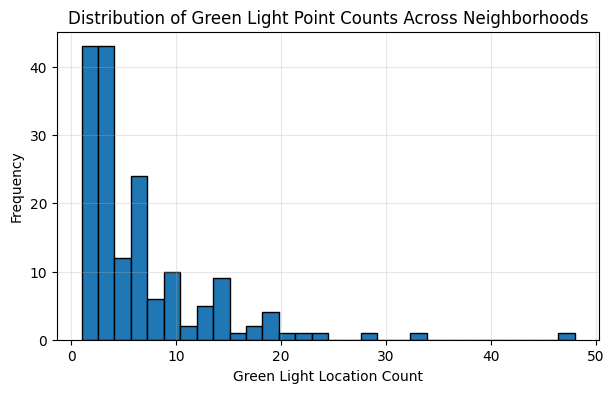

In [46]:
# Initialize the plot
plt.figure(figsize = (7, 4))

# Create the histogram with 30 bins
plt.hist(density_of_green_light_points['points'], 
         bins = 30, 
         edgecolor = 'black'
)

# Style the histogram
plt.xlabel('Green Light Location Count')
plt.ylabel('Frequency')
plt.title('Distribution of Green Light Point Counts Across Neighborhoods')
plt.grid(True, alpha = 0.3)

plt.show()

The vast majority of the neighborhoods have less than 20 Green Light locations. There is a neighborhood that has 45-50 locations. Let's see which neighborhood that is:

In [47]:
# Return row with highest total points
max_points_row = density_of_green_light_points.loc[
    density_of_green_light_points['points'].idxmax()
]
print("Neighborhood with most points:")
print(max_points_row)

Neighborhood with most points:
neighborhood_name     Franklin Park
points                           48
points_per_sq_mile             31.5
council_district                  7
Name: 7, dtype: object


With 48 total Green Light locations, **Franklin Park neighborhood contains the most Green Light locations out of all Current City of Detroit Neighborhoods**.

Now let's look at the distribution of the neighborhood Green Light densities.

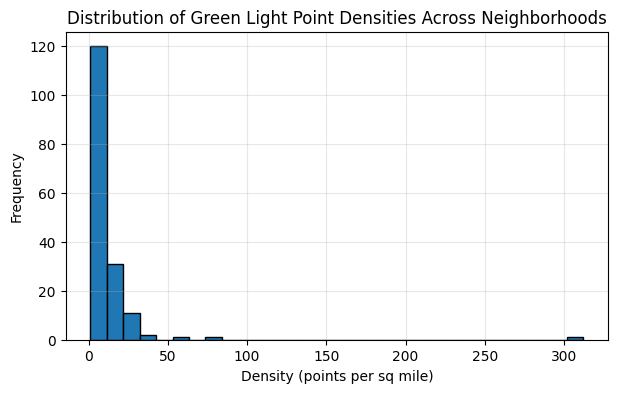

In [48]:
# Initialize the plot
plt.figure(figsize = (7, 4))

# Create the histogram with 30 bins
plt.hist(density_of_green_light_points['points_per_sq_mile'], 
         bins = 30, 
         edgecolor = 'black'
)

# Style the histogram
plt.xlabel('Density (points per sq mile)')
plt.ylabel('Frequency')
plt.title('Distribution of Green Light Point Densities Across Neighborhoods')
plt.grid(True, alpha = 0.3)

plt.show()

The majority of neighborhood Green Light densities are from 0-20 locations per square mile. You can see there is an outlier that has a density of about 310 points per square mile. Let's find out which neighborhood that is.

In [49]:
# Return row with highest points per square mile
max_density_row = density_of_green_light_points.loc[
    density_of_green_light_points['points_per_sq_mile'].idxmax()
]
print("Neighborhood with highest density (points per sq mile):")
print(max_density_row)

Neighborhood with highest density (points per sq mile):
neighborhood_name     Greektown
points                       15
points_per_sq_mile        312.2
council_district              5
Name: 0, dtype: object


With a density of 312.2 points per square mile, **Greektown has the highest concentration of Green Light locations out of all Current City of Detroit Neighborhoods**.

The above insight requires context, as Greektown only has an area of just 0.05 square miles and there are 15 Green Light surveillance cameras in that tiny area. The density comes out to 312 cameras per square mile. This may be misleading if presented without sufficient context.

Also, Greektown is not a residential neighborhood. What would it look like if we filtered out neighborhoods that are not primarily residential?

Let's filter out neighborhoods that are mostly parks, commercial, or industrial/airport.

In [50]:
non_residential_neighborhoods = {
    'Belle Isle': 'Park',
    'Palmer Park': 'Park',
    'Rouge Park': 'Park',
    'Chene Park': 'Park',
    'Dequindre Cut': 'Park',
    'Campus Martius': 'Park',
    'Greektown': 'Commercial',
    'Downtown': 'Commercial',
    'Cobo / TCF / Riverfront': 'Commercial',
    'Detroit Metropolitan Airport': 'Institutional',
    'Industrial Parcels': 'Institutional'
}

non_residential_names = set(non_residential_neighborhoods.keys())

green_light_gdf_residential = density_of_green_light_points[~density_of_green_light_points["neighborhood_name"].isin(non_residential_names)].copy()

green_light_gdf_residential.head()

,neighborhood_name,points,points_per_sq_mile,council_district
1,New Center Commons,12,76.1,5
2,Mexicantown,7,60.4,6
3,Pilgrim Village,29,40.1,2
4,West Village,5,35.4,5
5,Mohican Regent,12,31.7,3


Now let's see which residential neighborhood has the most Green Light locations:

In [51]:
# Return row with highest total points
max_points_row = green_light_gdf_residential.loc[
    green_light_gdf_residential['points'].idxmax()
]
print("Neighborhood with most points:")
print(max_points_row)

Neighborhood with most points:
neighborhood_name     Franklin Park
points                           48
points_per_sq_mile             31.5
council_district                  7
Name: 7, dtype: object


Since Franklin Park is residential, it remains the neighborhood with the most Green Light locations after filtering out non-residential.

Let's see how the spread of the total locations per neighborhood changes when we are only looking at residential neighborhoods.

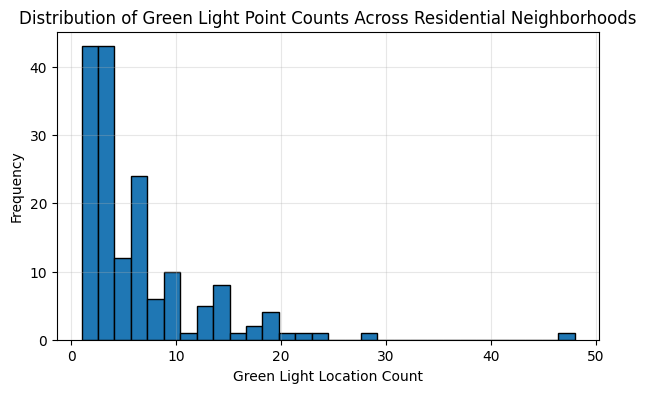

In [52]:
# Initialize the plot
plt.figure(figsize = (7, 4))

# Create the histogram with 30 bins
plt.hist(green_light_gdf_residential['points'], 
         bins = 30, 
         edgecolor = 'black'
)

# Style the histogram
plt.xlabel('Green Light Location Count')
plt.ylabel('Frequency')
plt.title('Distribution of Green Light Point Counts Across Residential Neighborhoods')
plt.grid(True, alpha = 0.3)

plt.show()

There wasn't a noticeable difference in the spread of counts.

Let's look at the density distribution for residential neighborhoods.

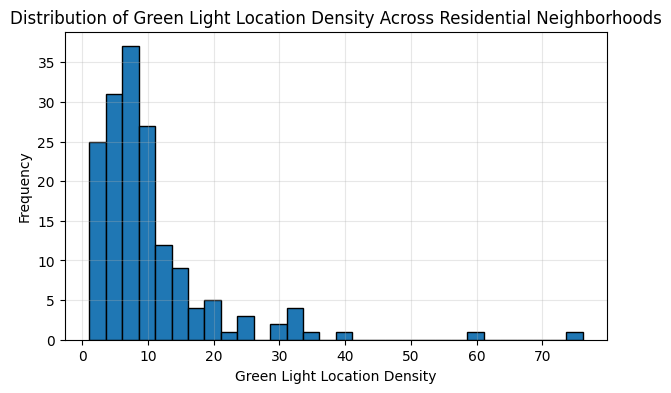

In [53]:
# Initialize the plot
plt.figure(figsize = (7, 4))

# Create the histogram with 30 bins
plt.hist(green_light_gdf_residential['points_per_sq_mile'], 
         bins = 30, 
         edgecolor = 'black'
)

# Style the histogram
plt.xlabel('Green Light Location Density')
plt.ylabel('Frequency')
plt.title('Distribution of Green Light Location Density Across Residential Neighborhoods')
plt.grid(True, alpha = 0.3)

plt.show()

There was a noticeable difference in the spread of the density when we filter out non-residential neighborhoods. Now, the highest density of Green Light locations is around 75! Let's see which residential neighborhood has the highest density of Green light locations:

In [54]:
# Return row with highest points per square mile
max_density_row = green_light_gdf_residential.loc[
    green_light_gdf_residential['points_per_sq_mile'].idxmax()
]
print("Neighborhood with highest density (points per sq mile):")
print(max_density_row)

Neighborhood with highest density (points per sq mile):
neighborhood_name     New Center Commons
points                                12
points_per_sq_mile                  76.1
council_district                       5
Name: 1, dtype: object


After filtering out non-residential, **New Center Commons neighborhood has the highest concentration of Green Light locations out of all residential Current City of Detroit Neighborhoods**.

Let's look at the Green Light Locations data grouped by council district. For each council district, we will calculate the average, minimum, and maximum number of Green Light locations in the district's neighborhoods.

In [55]:
council_stats = council_district_stats(
    neighborhood_density_df = green_light_gdf_residential,
    council_col = 'council_district',
    neighborhood_col = 'neighborhood_name',
    density_col = 'points_per_sq_mile',
    points_col = 'points'
)

council_stats

,council_district,avg_points_per_sq_mile,min_points_per_sq_mile,max_points_per_sq_mile,total_points,min_neighborhood,max_neighborhood
0,5,12.7,2.2,76.1,191,Gratiot Woods,New Center Commons
1,2,11.9,2.8,40.1,162,Penrose,Pilgrim Village
2,6,10.8,1.1,60.4,115,Carbon Works,Mexicantown
3,7,10.2,2.1,31.5,194,Aviation Sub,Franklin Park
4,1,9.8,1.3,31.7,127,Brightmoor,Cadillac Community
5,4,7.9,1.9,17.0,127,Wade,Jefferson Chalmers
6,3,7.1,1.6,31.7,110,Cadillac Heights,Mohican Regent


We could look at the spread of the counts and densities for the council districts, but there aren't enough districts to create an impactful visualization or plot from the few council districts.

Which council district has the most Green Light locations?

In [56]:
# Council district with highest total points
max_points_council = council_stats.loc[
    council_stats['total_points'].idxmax()
]
print("Council district with most points:")
print(max_points_council)

Council district with most points:
council_district                      7
avg_points_per_sq_mile             10.2
min_points_per_sq_mile              2.1
max_points_per_sq_mile             31.5
total_points                        194
min_neighborhood           Aviation Sub
max_neighborhood          Franklin Park
Name: 3, dtype: object


**With 192 points, Council District 7 has the higher number of Green Light locations.**

In [57]:
# Row with highest average density at council level
max_density_council = council_stats.loc[
    council_stats['avg_points_per_sq_mile'].idxmax()
]
print("Council district with highest average density:")
print(max_density_council)

Council district with highest average density:
council_district                           5
avg_points_per_sq_mile                  12.7
min_points_per_sq_mile                   2.2
max_points_per_sq_mile                  76.1
total_points                             191
min_neighborhood               Gratiot Woods
max_neighborhood          New Center Commons
Name: 0, dtype: object


**With a density of 12.7 Green Light locations per square mile, Council District 5 has the highest concentration of Green Light cameras.**

We can also visualize this data on a map! Here we create a map that shows each Green Light surveillance camera location layered on the current neighborhood boundaries.

In [58]:
# display a map of the points overlaid onto the neighborhoods
# color coded by council district
# with hover menu to show council district, neighborhood name, and business name for each point

m = points_in_neighborhood_map(
    point_layers = {"Green Light locations": green_light_gdf},
    neighborhoods_gdf = current_neighborhoods_gdf,
    council_col = "council_district",
    neighborhood_col = "neighborhood_name",
    point_info_col = "business_name",
    point_base_color = "green",
    point_radius = 2,
    title = "Green Light Locations",
    subtitle = "by Neighborhood and Council District"
    )

m

This map is interesting! The Green Light location points tend to be positioned in rows and clusters. The places on the map where there is a line of green points indicate a street with a strong surveillance presence.

## Medically Underserved Areas/Population

In the Medically Underserved Areas Population (MUAP) data, each record represents an Area or Population that has been classified as Medically Underserved with the Index of Medical Underservice (IMU).

The Index of Medical Underservice (IMU) (shown here as "med_underserv_ranking") is calculated by the Health Resources and Services Administration in the US Department of Health and Human Services. 

IMU is calculated using four criteria:
- population to provider ratio
- percent of the population below the federal poverty level
- percent of the population over age 65
- infant mortality rate

The IMU Index ranges from 0 to 100, with 0 being the lowest possible level of medical underservice (lower IMU = greater level of medical underservice). An Area or Population with an IMU of 62 or below qualifies for a MUA/P designation. (https://bhw.hrsa.gov/workforce-shortage-areas/shortage-designation/scoring)

Since this dataset contains MUA/P designations within the City of Detroit, there are no records for areas/populations that did not qualify for a MUA/P designation. In other words, there are no records for areas that had an IMU Index higher than 62.

Let's begin by looking at some summary statistics from the dataset.

In [59]:
summarize_dataframe(medically_underserved_gdf)

,Type,Missing,Missing %,Unique,min,max,mean
ObjectId,int64,0,0.0,216,1.0,216.0,108.50
med_underserv_ranking,float64,0,0.0,13,32.5,61.7,46.31
geometry,geometry,0,0.0,203,NaN,NaN,NaN


There are 216 unique "ObjectIDs". Each ObjectId represents a Medically Underserved Area or Population.

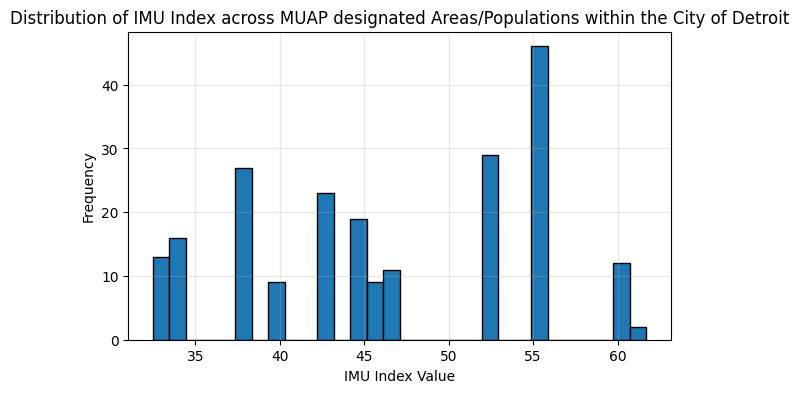

In [60]:
# Initialize the figure
plt.figure(figsize = (7, 4))

# Create the histogram
plt.hist(
    medically_underserved_gdf['med_underserv_ranking'], 
    bins = 30, 
    edgecolor = 'black'
)

# Style the plot
plt.xlabel('IMU Index Value')
plt.ylabel('Frequency')
plt.title('Distribution of IMU Index across MUAP designated Areas/Populations within the City of Detroit')
plt.grid(True, alpha = 0.3)

plt.show()

Let's start visualizing the data on the map. We can overlay a map of neighborhoods with the color-coded MUAP points.

In [61]:
# Display a map of neighborhoods with medically underserved areas points on top, 
# with dot color corresponding to medical_underservice_ranking (IMU)

point_layers = {
    "Medically Underserved Areas": medically_underserved_gdf
    #"Other Points": other_points_gdf
}

# Create map
m = points_in_neighborhood_map(
    point_layers = point_layers,
    neighborhoods_gdf = current_neighborhoods_gdf,
    council_col = "council_district",
    neighborhood_col = "neighborhood_name",
    point_base_color = "red",
    point_info_col = "med_underserv_ranking",
    ranking_col = "med_underserv_ranking",
    point_radius = 2,
    point_opacity = 0.6,
    start_zoom = 12,
    title = "Medically Underserved Areas",
    subtitle = "Rankings range from 32 (dark red) to 61 (light red)"
)

m

Is there is a noticeable pattern of medical underservice between council districts? We can calculate the average medical underservice ranking of each council district, weighted by area. Not every neighborhood has an IMU below 62. 

Neighborhoods that don't have any MUAPs will be assigned a "fallback value" of 70 to allow us to calculate an average by council district.

We will also only include neighborhoods that are primarily residential.

In [62]:
# Create dictionary of non-residential neighborhoods
non_residential_neighborhoods = {
    'Belle Isle': 'Park',
    'Palmer Park': 'Park',
    'Rouge Park': 'Park',
    'Chene Park': 'Park',
    'Dequindre Cut': 'Park',
    'Campus Martius': 'Park',
    'Greektown': 'Commercial',
    'Downtown': 'Commercial',
    'Cobo / TCF / Riverfront': 'Commercial',
    'Detroit Metropolitan Airport': 'Institutional',
    'Industrial Parcels': 'Institutional'
}

# Create a set of non-residential neighborhoods
non_residential_names = set(non_residential_neighborhoods.keys())

district_level_imu = calculate_district_imu(
    current_neighborhoods_gdf,
    medically_underserved_gdf,
    district_col = "council_district",
    neighborhood_col = "neighborhood_name",
    imu_col = "med_underserv_ranking",
    non_residential_names = non_residential_names,
    fallback_value = 70
)

district_level_imu.head(7)

,council_district,area_weighted_IMU,lowest_ranked_neighborhood,lowest_neighborhood_IMU
0,6,47,Chadsey Condon,33.0
1,3,48,Airport Sub,42.4
2,7,49,Barton-McFarland,37.5
3,4,49,Chandler Park,33.6
4,5,51,Eastern Market,32.5
5,1,59,Hubbell-Lyndon,37.5
6,2,63,Bethune Community,37.5


**Council district 6 has the lowest average IMU index (with non-residential neighborhoods removed).**

## Improve Detroit Issues

There are 686,281 requests in the Improve Detroit DataFrame, and when we converted it to a GeoDataFrame, we are left with 41,158 requests.

In [63]:
41158 / 686281

0.05997251854561032

Only 6% of the records in the DataFrame have latitude and longitude columns. This means that 94% of the requests are excluded from the GeoDataFrame.

How will this missing data skew our analysis?

**Bias from missing location data**

Let's explore how requests with location information vary across neighborhoods. We can start by calculating the density of Improve Detroit app service requests per neighborhood

In [64]:
# Count number of requests per neighborhood
requests_by_neighborhood = (
    improve_detroit_gdf
        .groupby("neighborhood")
        .size()
        .reset_index(name="request_count")
)

# Left join request counts to current_neighborhoods_gdf
neighborhoods_with_counts_gdf = current_neighborhoods_gdf.merge(
    requests_by_neighborhood,
    left_on = "neighborhood_name",
    right_on = "neighborhood",
    how = "left"
)

# Fill missing request counts (neighborhoods with no requests)
neighborhoods_with_counts_gdf["request_count"] = (
    neighborhoods_with_counts_gdf["request_count"].fillna(0)
)

# Calculate request density
neighborhoods_with_counts_gdf["request_density"] = (
    neighborhoods_with_counts_gdf["request_count"]
        .div(neighborhoods_with_counts_gdf["area_sq_miles"])
        .replace([float("inf"), -float("inf")], 0)
        .fillna(0)
        .round()
        .astype(int)
)

# Sort by density desc
neighborhoods_with_counts_gdf = neighborhoods_with_counts_gdf.sort_values(
    by = "request_density",
    ascending = False
)

# View result
neighborhoods_with_counts_gdf[[
    "neighborhood_name",
    "council_district",
    "request_count",
    "area_sq_miles",
    "request_density",
    "geometry"
]].head()


,neighborhood_name,council_district,request_count,area_sq_miles,request_density,geometry
169,Russell Woods,7,3163.0,0.31,10203,"POLYGON ((13457303.974 326468.649, 13457435.21..."
93,Hubbell-Puritan,1,2631.0,0.37,7111,"POLYGON ((13442507.87 333572.767, 13442240.289..."
155,Pingree Park,5,1725.0,0.25,6900,"POLYGON ((13491677.208 319288.354, 13491136.64..."
6,Belmont,1,1566.0,0.25,6264,"POLYGON ((13441448.45 330870.001, 13441446.159..."
75,Gratiot Woods,5,2210.0,0.45,4911,"POLYGON ((13494230.87 320819.763, 13494229.243..."


In [65]:
# Find the neighborhood with the highest density
max_density_idx = neighborhoods_with_counts_gdf['request_density'].idxmax()
max_density_neighborhood = neighborhoods_with_counts_gdf.loc[max_density_idx, 'neighborhood_name']
max_density_value = neighborhoods_with_counts_gdf.loc[max_density_idx, 'request_density']

print(f"Highest density neighborhood: {max_density_neighborhood} ({max_density_value:.2f} requests/sq mile)")

Highest density neighborhood: Russell Woods (10203.00 requests/sq mile)


**The Russell Woods neighborhood has the highest request density (out of requests with location data).**

Display chloropleth map to show num of service requests for each neighborhood and council district

The above attempt was fruitless. 

In [66]:
def neighborhood_density_highlight(
    neighborhoods_gdf: gpd.GeoDataFrame,
    value_col: str = "request_count",
    council_col: str = "council_district",
    neighborhood_col: str = "neighborhood_name",
    area_col: str = "area_sq_miles",
    start_zoom: int = 12,
    title: str = None,
    subtitle: str = None
):
    """
    Choropleth map showing neighborhoods in council districts, highlighting
    the neighborhood with highest density per council.
    Highlighted neighborhood: same council color, higher opacity, thick black outline.
    Title and subtitle appear in the top-left corner.
    """
    
    neighborhoods = neighborhoods_gdf.copy().to_crs(epsg=4326)
    
    # Fill missing counts
    neighborhoods[value_col] = neighborhoods[value_col].fillna(0)
    
    # Compute request density
    neighborhoods['request_density'] = (neighborhoods[value_col] / neighborhoods[area_col]).astype(int)
    
    # Max-density neighborhood per council district
    max_density_per_council = neighborhoods.loc[
        neighborhoods.groupby(council_col)['request_density'].idxmax()
    ]
    highlight_neighborhoods = set(max_density_per_council[neighborhood_col])
    
    # Council district colors
    unique_vals = neighborhoods[council_col].dropna().unique()
    num_colors = len(unique_vals)
    cmap = cmo.phase
    colors = [mcolors.rgb2hex(cmap(i / max(num_colors - 1, 1))) for i in range(num_colors)]
    council_color_map = {val: colors[i] for i, val in enumerate(unique_vals)}
    
    # Map center (re-project for accurate centroid)
    # Project to meters for centroid calculation
    neighborhoods_proj = neighborhoods.to_crs(epsg = 3857)
    centroids = neighborhoods_proj.geometry.centroid
    center_x, center_y = centroids.x.mean(), centroids.y.mean()
    
    # Convert back to lat/lon
    center_point = gpd.GeoSeries(
        [Point(center_x, center_y)], crs = 3857
    ).to_crs(epsg = 4326)
    center_lat, center_lon = center_point.y.values[0], center_point.x.values[0]
    
    m = folium.Map(location = [center_lat, center_lon], zoom_start = start_zoom)
    
    # Title and subtitle using MacroElement (works in notebooks and HTML)
    if title or subtitle:
        html_content = ""
        if title:
            html_content += f"<h4 style='margin:0'>{title}</h4>"
        if subtitle:
            html_content += f"<p style='margin:0'>{subtitle}</p>"
        
        template = """
        {% macro html(this, kwargs) %}
        <div style="
            position: fixed;
            top: 10px;
            left: 10px;
            z-index: 9999;
            background-color: rgba(255,255,255,0.85);
            padding: 5px 10px;
            border-radius: 5px;
            font-family: sans-serif;
        ">
            """ + html_content + """
        </div>
        {% endmacro %}
        """
        macro = MacroElement()
        macro._template = Template(template)
        m.get_root().add_child(macro)
    
    # Style function
    def style_function(feature):
        props = feature["properties"]
        council = props.get(council_col)
        neighborhood_name = props.get(neighborhood_col, None)
        
        # Base color
        base_color = council_color_map.get(council, "#cccccc")
        
        # Default style
        fill_color = mcolors.to_hex(mcolors.to_rgb(base_color))
        fill_opacity = 0.4
        weight = 0.5
        
        # Highlight max-density neighborhoods
        if neighborhood_name in highlight_neighborhoods:
            fill_opacity = 1  # more opaque
            weight = 3           # thicker black outline
        
        return {
            "fillColor": fill_color,
            "color": "black",
            "weight": weight,
            "fillOpacity": fill_opacity
        }
    
    # Tooltip (density as int)
    tooltip = folium.GeoJsonTooltip(
        fields = [council_col, neighborhood_col, value_col, 'request_density'],
        aliases = [
            "Council District:", 
            "Neighborhood:", 
            "Request Count:", 
            "Requests per sq mile:"
        ],
        localize = True,
        sticky = True
    )
    
    # Add GeoJson
    folium.GeoJson(
        neighborhoods,
        style_function = style_function,
        tooltip = tooltip,
        name = "Improve Detroit Service Requests"
    ).add_to(m)
    
    return m

In [67]:
m = neighborhood_density_highlight(
    neighborhoods_gdf = neighborhoods_with_counts_gdf,
    value_col = "request_count",
    council_col = "council_district",
    neighborhood_col = "neighborhood_name",
    area_col = "area_sq_miles",
    start_zoom = 12,
    title = "Improve Detroit Service Requests",
    subtitle = "Highlights show the neighborhood in each council district with the highest density of requests per square mile"
)

m